In [ ]:
# 라이브러리 불러오기
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
# 데이터 생성
from sklearn.datasets import load_diabetes # 당뇨병 환자 데이터

def make_dataset():
    dataset = load_diabetes()
    df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
    df['target'] = dataset.target
    X_train, X_test, y_train, y_test = train_test_split(
        df.drop('target', axis=1), df['target'], test_size=0.2, random_state=1004)
    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = make_dataset()
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((353, 10), (89, 10), (353,), (89,))

In [ ]:
# train 샘플
X_train.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
152,-0.034575,0.050680,-0.000817,0.070072,0.039710,0.066952,-0.065491,0.108111,0.026717,0.073480
417,-0.052738,-0.044642,0.071397,-0.074527,-0.015328,-0.001314,0.004460,-0.021412,-0.046883,0.003064
172,0.041708,0.050680,0.071397,0.008101,0.038334,0.015909,-0.017629,0.034309,0.073407,0.085907
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
296,0.067136,-0.044642,-0.061174,-0.040099,-0.026336,-0.024487,0.033914,-0.039493,-0.056153,-0.059067


In [ ]:
# 타겟 샘플
y_train.head()

,target
152,292.0
417,55.0
172,295.0
438,104.0
296,89.0


<Axes: >

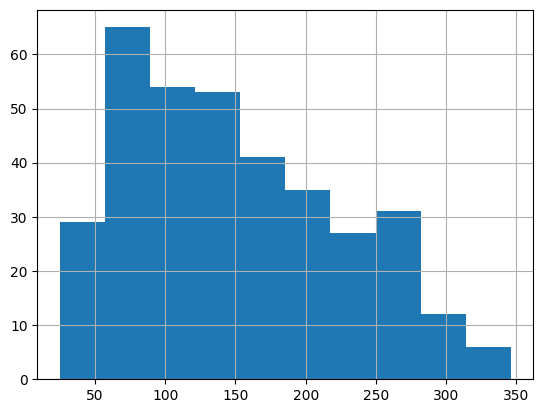

In [ ]:
# 타겟 확인
y_train.hist()

# 선형회귀

In [ ]:
# 선형회귀
# 모델 생성 + 예측값 도출
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)
pred = model.predict(X_test)
# 모델 평가
mean_squared_error(y_test, pred)

2707.6318521641583

# 릿지 회귀(L2)

In [ ]:
# 릿지회귀
# 모델 생성 + 예측값 도출
from sklearn.linear_model import Ridge
model = Ridge()
model.fit(X_train, y_train)
pred = model.predict(X_test)
# 모델 평가 -> 선형회귀 보다 MSE 커짐 -> 성능하락
mean_squared_error(y_test, pred)

3522.1191842072667

In [ ]:
# 회귀 계수 저장 및 데이터 프레임 변경, 변수지정
# alpha1 : 릿지모델 기본 alpha값
coef = pd.DataFrame(data=model.coef_, index=X_train.columns, columns = ['alpha1'])
coef


,alpha1
age,31.293421
sex,-71.448655
bmi,267.605962
bp,197.362492
s1,14.613257
s2,-13.884237
s3,-124.649836
s4,106.212967
s5,221.068493
s6,101.202546


In [ ]:
# 릿지회귀 (alpha=10)
from sklearn.linear_model import Ridge
model = Ridge(alpha=10)
model.fit(X_train, y_train)
pred = model.predict(X_test)
# 모델 평가 -> MSE 커짐 -> 성능하락
mean_squared_error(y_test, pred)

5521.884843903383

In [ ]:
# 회귀계수 저장
coef['alpha10'] = model.coef_
coef

,alpha1,alpha10
age,31.293421,16.703166
sex,-71.448655,-1.796418
bmi,267.605962,61.026376
bp,197.362492,47.434846
s1,14.613257,18.491238
s2,-13.884237,13.440104
s3,-124.649836,-35.542087
s4,106.212967,38.896140
s5,221.068493,55.276290
s6,101.202546,35.868345


In [ ]:
# 릿지회귀 (alpha=0.1)
from sklearn.linear_model import Ridge
model = Ridge(alpha=0.1)
model.fit(X_train, y_train)
pred = model.predict(X_test)
# 모델 평가 -> MSE 줄어듦, 선형회귀와 비슷
mean_squared_error(y_test, pred)

2744.9026742146693

In [ ]:
# 회귀계수 저장
coef['alpha0.1'] = model.coef_
coef

,alpha1,alpha10,alpha0.1
age,31.293421,16.703166,4.275162
sex,-71.448655,-1.796418,-205.210484
bmi,267.605962,61.026376,450.909749
bp,197.362492,47.434846,331.923682
s1,14.613257,18.491238,-84.311149
s2,-13.884237,13.440104,-54.662514
s3,-124.649836,-35.542087,-158.706512
s4,106.212967,38.896140,114.066890
s5,221.068493,55.276290,391.231834
s6,101.202546,35.868345,78.555458


In [ ]:
# 릿지회귀 (alpha=0.05)
from sklearn.linear_model import Ridge
model = Ridge(alpha=0.05)
model.fit(X_train, y_train)
pred = model.predict(X_test)
# 모델 평가 -> MSE 계속 줄어듦
mean_squared_error(y_test, pred)

2699.6595785438317

In [ ]:
# 회귀계수 저장
coef['alpha0.05'] = model.coef_
coef
# alpha 값을 줄이면 회귀계수가 늘어가는 경향이 보인다.

,alpha1,alpha10,alpha0.1,alpha0.05
age,31.293421,16.703166,4.275162,-0.508850
sex,-71.448655,-1.796418,-205.210484,-223.345659
bmi,267.605962,61.026376,450.909749,469.447848
bp,197.362492,47.434846,331.923682,348.368885
s1,14.613257,18.491238,-84.311149,-146.952481
s2,-13.884237,13.440104,-54.662514,-18.297550
s3,-124.649836,-35.542087,-158.706512,-141.658486
s4,106.212967,38.896140,114.066890,115.860926
s5,221.068493,55.276290,391.231834,432.508101
s6,101.202546,35.868345,78.555458,69.578796


# 라쏘회귀(L1)

In [ ]:
# 라쏘회귀
# 모델 생성 + 예측값 도출
from sklearn.linear_model import Lasso
model = Lasso()
model.fit(X_train, y_train)
pred = model.predict(X_test)
# 모델 평가 -> 선형회귀 보다 MSE 커짐 -> 성능하락
mean_squared_error(y_test, pred)

4179.152642946343

In [ ]:
# 회귀 계수 저장 및 데이터 프레임 변경, 변수지정
# 릿지와 비교하면, 정말 중요하다고 생각되는 피쳐 말고는 전부 0으로 만듦
coef_lasso = pd.DataFrame(data=model.coef_, index=X_train.columns, columns = ['alpha1'])
coef_lasso

,alpha1
age,0.000000
sex,-0.000000
bmi,343.589790
bp,46.369923
s1,0.000000
s2,0.000000
s3,-0.000000
s4,0.000000
s5,245.170617
s6,0.000000


In [ ]:
# 라쏘회귀 (alpha=2)
# 모델 생성 + 예측값 도출
from sklearn.linear_model import Lasso
model = Lasso(alpha=2)
model.fit(X_train, y_train)
pred = model.predict(X_test)
# 모델 평가 -> 선형회귀 보다 MSE 커짐 -> 성능하락
mean_squared_error(y_test, pred)

6398.637179449031

In [ ]:
# 회귀계수 저장
# alpha 값 커지니까 0이 되는 피쳐들이 많아짐
coef_lasso['alpha2'] = model.coef_
coef_lasso

,alpha1,alpha2
age,0.000000,0.000000
sex,-0.000000,0.000000
bmi,343.589790,42.963888
bp,46.369923,0.000000
s1,0.000000,0.000000
s2,0.000000,0.000000
s3,-0.000000,-0.000000
s4,0.000000,0.000000
s5,245.170617,0.000000
s6,0.000000,0.000000


In [ ]:
# 라쏘회귀 (alpha=0.05)
# 모델 생성 + 예측값 도출
from sklearn.linear_model import Lasso
model = Lasso(alpha=0.05)
model.fit(X_train, y_train)
pred = model.predict(X_test)
# 모델 평가 -> 선형회귀 보다 MSE 커짐 -> 성능하락
mean_squared_error(y_test, pred)

2703.4583679188177

In [ ]:
# 회귀계수 저장
# alpha 값 작아지니까 0이 되는 피쳐들이 적어짐
coef_lasso['alpha0.05'] = model.coef_
coef_lasso

,alpha1,alpha2,alpha0.05
age,0.000000,0.000000,-0.000000
sex,-0.000000,0.000000,-198.948213
bmi,343.589790,42.963888,487.198584
bp,46.369923,0.000000,340.490360
s1,0.000000,0.000000,-95.576361
s2,0.000000,0.000000,-0.000000
s3,-0.000000,-0.000000,-189.867452
s4,0.000000,0.000000,10.487703
s5,245.170617,0.000000,457.332197
s6,0.000000,0.000000,39.292925


# 엘라스틱넷 회귀

In [ ]:
# 엘라스틱넷 회귀
# 모델 생성 + 예측값 도출
from sklearn.linear_model import ElasticNet
model = ElasticNet()
model.fit(X_train, y_train)
pred = model.predict(X_test)
# 모델 평가 -> 선형회귀 보다 MSE 커짐 -> 성능하락
mean_squared_error(y_test, pred)

6539.270961171604

In [ ]:
# 엘라스틱넷 회귀 (alpha = 0.0001, l1_ratio=0.6)
# 모델 생성 + 예측값 도출
from sklearn.linear_model import ElasticNet
model = ElasticNet(alpha = 0.0001, l1_ratio=0.6)
model.fit(X_train, y_train)
pred = model.predict(X_test)
# 모델 평가 -> 1l 규제 비율 추가, MSE 개선
mean_squared_error(y_test, pred)

2675.6031657225312

# 랜덤포레스트 & XGBoost

In [ ]:
# 랜덤포레스트
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor()
model.fit(X_train, y_train)
pred = model.predict(X_test)
mean_squared_error(y_test, pred)

3417.117070786517

In [ ]:
# Xgboost
from xgboost import XGBRegressor
model = XGBRegressor()
model.fit(X_train, y_train)
pred = model.predict(X_test)
mean_squared_error(y_test, pred)

4265.475533439266

# 하이퍼 파라미터 튜닝

In [ ]:
# 라이브러리 불러오기
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

In [ ]:
# 하이퍼파라미터
# 시간이 오래 걸려 learning_rate와 subsample는 주석 처리함
params={# 'learning_rate':[0.07, 0.05],
        'max_depth':[3, 5, 7],
        'n_estimators':[100, 200],
        # 'subsample':[0.9, 0.8, 0.7]
        }

In [ ]:
# 데이터셋 로드
def make_dataset2():
    dataset = load_diabetes()
    df = pd.DataFrame(dataset.data, columns=dataset.feature_names)
    df['target'] = dataset.target
    return df.drop('target', axis=1), df['target']
X, y = make_dataset2()

## GridSearchCV

In [ ]:
# GridSearchCV
#  'max_depth':[3, 5, 7],  'n_estimators':[100, 200]만 적용 시 3분 내외
xgb = XGBRegressor()
grid = GridSearchCV(xgb, params, cv=3, n_jobs=-1) # 모델, 하이퍼파라미터, 교차검증횟수 순으로 입력
grid.fit(X, y)

GridSearchCV(cv=3,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, feature_weights=None,
                                    gamma=None, grow_policy=None,
                                    importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, max_bin=None,
                                    max_cat_threshold=None,
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'max_depth': [3, 5, 7], 'n_estimators': [100, 200]})

In [ ]:
# 최적의 하이퍼파라미터를 찾음
grid.best_params_

{'max_depth': 5, 'n_estimators': 100}

In [ ]:
# 하이퍼 파라미터 튜닝
# 최적값 적용
xgb = XGBRegressor(max_depth=5,
                   n_estimators=100)

xgb.fit(X_train, y_train) # 학습
pred = xgb.predict (X_test) # 예측 결과
mean_squared_error(y_test, pred) # MSE 계산

3631.6651596206466

## RandomizedSearchCV

In [ ]:
# Randomized Search
xgb = XGBRegressor()
grid = RandomizedSearchCV(xgb, params, cv=3, n_iter=10, n_jobs=-1)
# n_iter=10 -> 10번 시도하고 찾겠다
grid.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 6 is smaller than n_iter=10. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


RandomizedSearchCV(cv=3,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraints=None,
                                          learning_rate=None, max_bin=None,
                                          max_cat_threshold=None,
                                          max_cat_to_onehot=None,
                                          max_delta_step=None, max_depth=None,
                                          max_leaves=None,
                                          min_child_weight=None, missing=nan,
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=None,
                                          num_parallel_tree=None, ...),
                   n_jobs=-1,
                   param_distributions={'max_depth': [3, 5, 7],
                                        'n_estimators': [100, 200]})

In [ ]:
# 최적의 하이퍼파라미터를 찾음
grid.best_params_

{'n_estimators': 100, 'max_depth': 5}

## 평가(회귀)

In [ ]:
# MAE
from sklearn.metrics import mean_absolute_error
mean_absolute_error(y_test, pred)

50.42673106675738

In [ ]:
# MSE
from sklearn.metrics import mean_squared_error
mean_squared_error(y_test, pred)

3631.6651596206466

In [ ]:
# RMSE
import numpy as np
np.sqrt(mean_squared_error(y_test, pred))

np.float64(60.26329861217893)

In [ ]:
# RMSLE
from sklearn.metrics import mean_squared_log_error
np.sqrt(mean_squared_log_error(y_test, pred))

np.float64(0.44623994150292096)

In [ ]:
# R2
from sklearn.metrics import r2_score
r2_score(y_test, pred)

0.4453372094757383